<font size=10>**TASK 1 - MULTILABEL TEXT CLASSIFICATION**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

**Question**: *How well can we classify a restaurant’s cuisine type using the content of their reviews as input?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Multilabel Classification](#3)
    - [3.1 Specific Data Preparation](#3_1)
        - [3.1.1 Initial Text Preprocessing: Baseline Cleaning](#3_1_1)
            - [3.1.1.1 Removing Empty Restaurant Reviews](#3_1_1_1)
        - [3.1.2 Text Preprocessing: Removal of Standard Stopwords](#3_1_2)
            - [3.1.2.1 Removing Empty Restaurant Reviews](#3_1_2_1)
            - [3.1.2.2 Most Frequent Words by Category](#3_1_2_2)
        - [3.1.3 Text Preprocessing: Removal of Custom Words](#3_1_3)
        - [3.1.4 Multilabel Datasets](#3_1_4)
            - [3.1.4.1 With Stopwords](#3_1_4_1)
            - [3.1.4.2 Without Standard Stopwords](#3_1_4_2)
                - [3.1.4.2.1 Tokenization](#3_1_4_2_1)
            - [3.1.4.3 Without Custom Stopwords](#3_1_4_3)
    - [3.2 Model Implementation](#3_2)
        - [3.2.1 Testing Models](#3_2_1)
        - [3.2.2 Grid Search](#3_2_2)
    - [3.3 Model Evaluation](#3_3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from nltk.tokenize import PunktSentenceTokenizer
sent_tokenizer = PunktSentenceTokenizer()
import plotly as px
import seaborn as sns
import plotly.express as px
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import ClassifierChain
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from tqdm.notebook import tqdm
from collections import defaultdict
from itertools import combinations
from skmultilearn.model_selection import iterative_train_test_split

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *
from classification_prep import *
from modelling import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [3]:
dataset_original = load_dataset('../data/02_atlanta_restaurant_slice_2023_translated.csv')

In [4]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,longitude,num_sentences,00_before_translating_cleaning,lang_langdetect,lang_langid,needs_translation,text_translated,text_for_pipeline
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,3349,33.779814,-84.410451,3,"One word amazing!! The red fish, halibut, frie...",en,en,False,"One word amazing!! The red fish, halibut, frie...","One word amazing!! The red fish, halibut, frie..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...,False,3349,33.779814,-84.410451,1,First time here and the food is great and the ...,en,en,False,First time here and the food is great and the ...,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...,False,3349,33.779814,-84.410451,14,I recently had the pleasure of dining at Optim...,en,en,False,I recently had the pleasure of dining at Optim...,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...,False,3349,33.779814,-84.410451,9,Beautiful atmosphere and delicious food . All ...,en,en,False,Beautiful atmosphere and delicious food . All ...,Beautiful atmosphere and delicious food . All ...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...,False,3349,33.779814,-84.410451,3,We had a wonderful dinner at the Optimist . Ou...,en,en,False,We had a wonderful dinner at the Optimist . Ou...,We had a wonderful dinner at the Optimist . Ou...


In [5]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53565 entries, 0 to 53564
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   title                           53565 non-null  object 
 1   categoryName                    53565 non-null  object 
 2   website                         50599 non-null  object 
 3   url                             53565 non-null  object 
 4   reviewsCount                    53565 non-null  int64  
 5   stars                           53565 non-null  float64
 6   text                            53565 non-null  object 
 7   is_chain                        53565 non-null  bool   
 8   total_reviews_by_title          53565 non-null  int64  
 9   latitude                        53565 non-null  float64
 10  longitude                       53565 non-null  float64
 11  num_sentences                   53565 non-null  int64  
 12  00_before_translating_cleaning  

| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [6]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Multilabel Classification**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

From the data exploration stage (Notebooks 01 and 02), several key insights emerged:

(*01_data_understtanding.ipynb*)
- The restaurant category with more restaurants its ``Mexican Restaurant`` with 8959 and at last ``Bar & grill`` with 1107 restaurants
- In our raw dataset, we observe that the **exact same review text** appears multiple times. (MultiLabel Problem)

(*02_general_data_prep.ipynb*)
- The majority of reviews in the `text` column are **short**, consisting of **1–2 sentences**. The `num_sentences` distribution supports this: 
    - median = $2$
    - $75^{th}$ percentile = $4$
    - maximum = $43$

    suggesting a few exceptionally long reviews.

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation </font> <a class="anchor" id="3_1"></a>
  
[Back to TOC](#toc)

To achieve the best possible predictions from our models, it is essential to properly preprocess the text data. We will create different versions of the reviews using various preprocessing techniques and parameter settings to determine which approach performs best.

### <font color='#BFD72F' size=6>3.1.1 Initial Text Preprocessing: Baseline Cleaning</font> <a class="anchor" id="3_1_1"></a>
  
[Back to TOC](#toc)

The dataset was first corrected for misspellings and typos using the correct_spelling_typos function from general_preprocessing.py, which was created in the notebook 02_data_preprocessing.ipynb.

In [7]:
#dataset = correct_tokens_column_string(dataset, 'text_for_pipeline', output_col='words_corrected')

In [8]:
#dataset.to_csv(
#    "../data/03_atlanta_restaurant_slice_2023_translated_corrected_tokens.csv",
#    index=False
#)

In [9]:
#dataset = load_dataset('../data/03_atlanta_restaurant_slice_2023_translated_corrected_tokens.csv')

In this first step, we create a normalized version of the dataset to analyze the text structure and category similarities **before** filtering.

We apply the `main_pipeline` with the following configuration:
* **Noise Removal:** Stripping emojis, hashtags, URLs, and punctuation to reduce noise.
* **Lemmatization (`lemmatized=True`):** Converting words to their base forms (e.g., "running" $\to$ "run") to consolidate the vocabulary.
* **Stopwords Retention (`no_stopwords=False`):** We intentionally **keep** stopwords (e.g., "the", "and", "is") at this stage. This allows us to observe the natural language distribution and similarity between categories before removing grammatical connectors.

In [13]:
# Part 1
dataset['with_stopwords_cleaned_review_body'] = dataset['text_for_pipeline'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=True
    )
)

#### <font color='#BFD72F' size=6>3.1.1.1 Removing Empty Restaurant Reviews</font> <a class="anchor" id="3_1_1_1"></a>
  
[Back to TOC](#toc)

Before proceeding with classification, we must handle "ghost" reviews—entries that became empty after our initial cleaning pipeline.
First, we analyze the `with_stopwords_cleaned_review_body` column. These are reviews where we have removed noise (URLs, emojis, special characters) but **kept** the stopwords.
* **Logic:** If a review is empty at this stage, it means the original text contained **no valid words** at all (e.g., a review containing only "!!!" or "🍔").
* **Action:** Since these rows contain zero linguistic information, we **drop them** from the dataset to prevent errors in the modeling phase.

In [14]:
empty_with_stopwords = (dataset["with_stopwords_cleaned_review_body"] == "").sum()

empty_spaces_with_stopwords = dataset["with_stopwords_cleaned_review_body"].str.strip().eq("").sum()

examples_with_stopwords = dataset[dataset["with_stopwords_cleaned_review_body"].str.strip() == ""]["with_stopwords_cleaned_review_body"].head(5)
print("Exactly empty reviews:", empty_with_stopwords)
print("Reviews with only spaces (or tabs):", empty_spaces_with_stopwords)
print("\nExamples of empty reviews:")
print(examples_with_stopwords)

Exactly empty reviews: 0
Reviews with only spaces (or tabs): 0

Examples of empty reviews:
Series([], Name: with_stopwords_cleaned_review_body, dtype: object)


In [15]:
empty_idx_with_stopwords = dataset[dataset["with_stopwords_cleaned_review_body"].str.strip() == ""].index

dataset.loc[empty_idx_with_stopwords, :]
dataset.drop(empty_idx_with_stopwords, inplace=True)
print((dataset["with_stopwords_cleaned_review_body"].str.strip() == "").sum())

0


### <font color='#BFD72F' size=6>3.1.2 Text Preprocessing: Removal of Standard Stopwords</font> <a class="anchor" id="3_1_2"></a>
  
[Back to TOC](#toc)

Now analyzing the similarity again after removing stopwords.

In [16]:
# Part 2
dataset['without_stopwords_cleaned_review_body'] = dataset['text_for_pipeline'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=True
    )
)

Next, we examine the `without_stopwords_cleaned_review_body` column.
* **Logic:** These are reviews that were not empty initially, but became empty **after** we removed common stopwords (like "the", "was", "and").
* **Meaning:** A review ending up here implies it was composed entirely of generic grammatical words (e.g., *"It was all..."*) and lacked specific nouns or adjectives relevant to the cuisine.
* **Action:** We calculate the count of these "hollow" reviews to understand how much data might be lost or rendered non-informative by stopword filtering.

#### <font color='#BFD72F' size=6>3.1.2.1 Removing empty restaurant reviews</font> <a class="anchor" id="3_1_2_1"></a>
  
[Back to TOC](#toc)

#### <font color='#BFD72F' size=6>3.1.2.2 Most frequent words by category</font> <a class="anchor" id="3_1_2_2"></a>
  
[Back to TOC](#toc)

To better understand what defines each cuisine, we extract the most frequent words associated with each category.
* **Method:** We use `CountVectorizer` to generate a "Bag of Words" representation of the text.
* **Filtering:** We exclude extremely rare words (`min_df=5`) and extremely common words (`max_df=0.8`) to focus on meaningful terms.
* **Goal:** By identifying the top 15 words for each category, we can visually verify if the categories are distinct (e.g., "taco" for Mexican vs. "sushi" for Japanese) or if they are still polluted by generic terms (e.g., "good", "place").

In [17]:
vectorizer = CountVectorizer(max_df=0.8, min_df=5)

X = vectorizer.fit_transform(dataset['without_stopwords_cleaned_review_body'])
words = vectorizer.get_feature_names_out()

# Sum counts across all documents
total_counts = X.sum(axis=0).A1

df_words = pd.DataFrame({
    'word': words,
    'count': total_counts
}).sort_values(by='count', ascending=False)

df_words.head(10)


,word,count
2828,food,29147
3118,great,18030
3057,good,16503
6081,service,16109
5120,place,9099
6992,time,7013
663,back,6449
4802,order,6033
807,best,5751
2007,delicious,5580


In [18]:
df_top = df_words.head(30)

treemap_chart(
    df_top,
    path_col=[px.Constant('All Reviews'), 'word'],
    value_col='count',
    title='Most Frequent Words in Atlanta Restaurant Reviews (All Categories)'
)


The graph reveals that generic terms such as **"food"**, **"service"** and **"good"** still dominate the top 15 words across multiple categories. 

### <font color='#BFD72F' size=6>3.1.3 Text Preprocessing: Removal of custom words</font> <a class="anchor" id="3_1_3"></a>
  
[Back to TOC](#toc)

The high-frequency words seen above may provide little discriminatory power for the classification task, as they appear in positive reviews regardless of the cuisine. To improve model performance, it may be beneficial to **refine the stopword list** by removing these common sentiment words. This will force the model to focus on category-specific vocabulary (e.g., "sushi", "taco", "burger") rather than generic praise.

In [19]:
# Part 3 - custom stopwords
dataset['without_custom_stopwords_cleaned_review_body'] = dataset['text_for_pipeline'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=['food', 'good', 'service', 'great'],
        stopwords_tokeep=[],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=True
    )
)

### <font color='#BFD72F' size=6>3.1.4 Multilabel datasets</font> <a class="anchor" id="3_1_4"></a>
  
[Back to TOC](#toc)

#### <font color='#BFD72F' size=6>3.1.4.1 With Stopwords</font> <a class="anchor" id="3_1_4_1"></a>
  
[Back to TOC](#toc)

In [20]:
mlb_with_stopwords = (
    dataset.groupby("with_stopwords_cleaned_review_body")["categoryName"]
      .apply(lambda x: sorted(set(x)))   
      .reset_index()
      .rename(columns={"categoryName": "categories"})
)

display(mlb_with_stopwords)
mlb_with_stopwords.info()

,with_stopwords_cleaned_review_body,categories
0,!!service and ambience were great the food was...,[New American restaurant]
1,0 stars rat droppings on the floor in the last...,[Chinese restaurant]
2,0 stars to give one to review terrible whole e...,[Fast food restaurant]
3,0 stars would be more appropriate called and a...,[American restaurant]
4,03 made rsvp for 630p arrived roughly 15 mins ...,[American restaurant]
...,...,...
50346,zero stars if i could this mcdonald s claims t...,[Fast food restaurant]
50347,zero stars the food totally upset my stomach t...,[Italian restaurant]
50348,zero zero zero stars horrible horrible experie...,[American restaurant]
50349,zucchini fries were banging great place,[Pizza restaurant]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50351 entries, 0 to 50350
Data columns (total 2 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   with_stopwords_cleaned_review_body  50351 non-null  object
 1   categories                          50351 non-null  object
dtypes: object(2)
memory usage: 786.9+ KB


In [21]:
category_counts = mlb_with_stopwords['categories'].apply(len)

count_by_n = category_counts.value_counts().sort_index()

df_plot = pd.DataFrame({
    "num_categories": count_by_n.index,
    "num_comments": count_by_n.values
})

df_plot_filtered = df_plot[df_plot["num_categories"] > 1]

In [22]:
bar_chart(
    data=df_plot_filtered,
    x="num_categories",
    y="num_comments",
    title="Number of Comments with More Than 1 Category for Exploratory Baseline",
    labels={
        "num_categories": "Number of Categories",
        "num_comments": "Number of Comments"
    },
    top_n=len(df_plot_filtered)  # ensure all appear
)


There are 4 comments with all 17 categories assigned to them:

In [48]:
mlb_with_stopwords[mlb_with_stopwords['categories'].apply(len) == 17]

,with_stopwords_cleaned_review_body,categories
8913,excellent,"[American restaurant, Bar & grill, Barbecue re..."
13648,good,"[American restaurant, Bar & grill, Barbecue re..."
13914,good food,"[American restaurant, Bar & grill, Barbecue re..."
15968,great food,"[American restaurant, Bar & grill, Barbecue re..."
16235,great food and service,"[American restaurant, Bar & grill, Breakfast r..."


In [24]:
mlb_with_stopwords = mlb_with_stopwords[mlb_with_stopwords['with_stopwords_cleaned_review_body'].apply(lambda x: len(x.split()) > 2)]

In multi-label classification, labels are rarely independent. To visualize the relationships between different cuisine types, we construct a **Co-Occurrence Matrix**.

In [25]:
mlb_with_stopwords["categories_tuple"] = mlb_with_stopwords["categories"].apply(lambda x: tuple(sorted(x)))


all_cats = sorted({cat for cats in mlb_with_stopwords["categories"] for cat in cats})

co_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

co_counts = []


for cats in mlb_with_stopwords["categories"]:
    for c1, c2 in combinations(cats, 2):  # todas as combinações de 2
        co_matrix.loc[c1, c2] += 1
        co_matrix.loc[c2, c1] += 1

for c1 in co_matrix.index:
    for c2 in co_matrix.columns:
        if c1 < c2 and co_matrix.loc[c1, c2] > 0:
            co_counts.append((c1, c2, co_matrix.loc[c1, c2]))

# ordenar
co_counts_sorted = sorted(co_counts, key=lambda x: x[2], reverse=True)

for cat in all_cats:
    co_matrix.loc[cat, cat] = 0

heatmap_chart(co_matrix,
              title="Category Co-Occurrence Matrix in Exploratory Baseline",)

The resulting heatmap highlights clusters of strongly related categories.
* **Diagonal:** We set the diagonal to zero to ignore self-correlation and focus purely on cross-category relationships.
* **Key Finding:** We look for "hot spots" (high values). For example, if ``Mexican restaurant`` and ``American & Steak House`` have a high co-occurrence count, it suggests they are frequently used interchangeably or describe the same establishments, supporting the case for merging them.

**However, it was decided NOT to join them because** they represent semantically distinct cuisines types.

#### <font color='#BFD72F' size=6>3.1.4.2 Without standard stopwords</font> <a class="anchor" id="3_1_4_2"></a>
  
[Back to TOC](#toc)

In [26]:
mlb_without_s_stopwords = (
    dataset.groupby("without_stopwords_cleaned_review_body")["categoryName"]
      .apply(lambda x: sorted(set(x)))   
      .reset_index()
      .rename(columns={"categoryName": "categories"})
)

display(mlb_without_s_stopwords)
mlb_without_s_stopwords.info()

,without_stopwords_cleaned_review_body,categories
0,,"[Chicken restaurant, Chinese restaurant, Fast ..."
1,!!service ambience great food good raw chicken...,[New American restaurant]
2,0 stars give one review terrible whole establi...,[Fast food restaurant]
3,0 stars option deserve pretty sloppy service f...,[Sandwich shop]
4,0 stars rat droppings floor last back booth ro...,[Chinese restaurant]
...,...,...
49622,zero stars thing put horrible staff including ...,[Breakfast restaurant]
49623,zero zero zero stars horrible horrible experie...,[American restaurant]
49624,zing salad loved,[Chicken restaurant]
49625,zucchini fries banging great place,[Pizza restaurant]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49627 entries, 0 to 49626
Data columns (total 2 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   without_stopwords_cleaned_review_body  49627 non-null  object
 1   categories                             49627 non-null  object
dtypes: object(2)
memory usage: 775.6+ KB


In [27]:
# Count the number of exactly empty reviews
empty_without_stopwords_s = (mlb_without_s_stopwords["without_stopwords_cleaned_review_body"] == "").sum()

# Count reviews that only have spaces or tabs
empty_spaces_without_stopwords_s = mlb_without_s_stopwords["without_stopwords_cleaned_review_body"].str.strip().eq("").sum()

# Show examples (first 10)
examples_without_stopwords_s = mlb_without_s_stopwords[mlb_without_s_stopwords["without_stopwords_cleaned_review_body"].str.strip() == ""]["without_stopwords_cleaned_review_body"].head(5)

print("Exactly empty reviews:", empty_without_stopwords_s)
print("Reviews with only spaces (or tabs):", empty_spaces_without_stopwords_s)

Exactly empty reviews: 1
Reviews with only spaces (or tabs): 1


In [28]:
empty_idx_without_stopwords_s = mlb_without_s_stopwords[mlb_without_s_stopwords["without_stopwords_cleaned_review_body"].str.strip() == ""].index

#show the rows with empty cleaned reviews
mlb_without_s_stopwords.loc[empty_idx_without_stopwords_s, :]

,without_stopwords_cleaned_review_body,categories
0,,"[Chicken restaurant, Chinese restaurant, Fast ..."


In [29]:
mlb_without_s_stopwords.drop(empty_idx_without_stopwords_s, inplace=True)

##### <font color='#BFD72F' size=6>3.1.4.2.1 Tokenization Without Stopwords</font> <a class="anchor" id="3_1_4_2_1"></a>
  
[Back to TOC](#toc)

In order to facilitate further experiments with Doc2Vec vectorization in the modeling phase, we created a new preprocessed column in which the comments were tokenized. This ensures that the dataset is ready for vectorization whenever needed.

In [30]:
mlb_without_s_stopwords['without_stopwords_tokenized_cleaned_review_body'] = mlb_without_s_stopwords['without_stopwords_cleaned_review_body'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=True,
        stemmed=False,
        treat_repeated_chars=True
    )
)

#### <font color='#BFD72F' size=6>3.1.4.2.2 Light Dataset Exploration</font> <a class="anchor" id="P3.1.4.2.2"></a>
  
[Back to TOC](#toc)

In [31]:
category_counts = mlb_with_stopwords['categories'].apply(len)

count_by_n = category_counts.value_counts().sort_index()

df_plot = pd.DataFrame({
    "num_categories": count_by_n.index,
    "num_comments": count_by_n.values
})

df_plot_filtered = df_plot[df_plot["num_categories"] > 1]

In [32]:
bar_chart(
    data=df_plot_filtered,
    x="num_categories",
    y="num_comments",
    title="Number of Comments with More Than 1 Category for Standard Filtration",
    labels={
        "num_categories": "Number of Categories",
        "num_comments": "Number of Comments"
    },
    top_n=len(df_plot_filtered)  # ensure all appear
)

In [ ]:
mlb_without_s_stopwords[mlb_without_s_stopwords['categories'].apply(len) == 17]

,without_stopwords_cleaned_review_body,categories,without_stopwords_tokenized_cleaned_review_body
9617,delicious,"[American restaurant, Bar & grill, Barbecue re...",[delicious]
12212,excellent,"[American restaurant, Bar & grill, Barbecue re...",[excellent]
20335,good,"[American restaurant, Bar & grill, Barbecue re...",[good]
20747,good food,"[American restaurant, Bar & grill, Barbecue re...","[good, food]"
21001,good food good service,"[American restaurant, Bar & grill, Breakfast r...","[good, food, good, service]"
21303,good food service,"[American restaurant, Bar & grill, Barbecue re...","[good, food, service]"
23551,great food,"[American restaurant, Bar & grill, Barbecue re...","[great, food]"
24063,great food great service,"[American restaurant, Bar & grill, Barbecue re...","[great, food, great, service]"
24428,great food service,"[American restaurant, Bar & grill, Barbecue re...","[great, food, service]"
34395,ok,"[American restaurant, Bar & grill, Breakfast r...",[ok]


In [34]:
mlb_without_s_stopwords = mlb_without_s_stopwords[mlb_without_s_stopwords['without_stopwords_cleaned_review_body'].apply(lambda x: len(x.split()) > 2)]

In [35]:
mlb_without_s_stopwords["categories_tuple"] = mlb_without_s_stopwords["categories"].apply(lambda x: tuple(sorted(x)))


all_cats = sorted({cat for cats in mlb_with_stopwords["categories"] for cat in cats})

co_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

co_counts = []


for cats in mlb_without_s_stopwords["categories"]:
    for c1, c2 in combinations(cats, 2):  # todas as combinações de 2
        co_matrix.loc[c1, c2] += 1
        co_matrix.loc[c2, c1] += 1

for c1 in co_matrix.index:
    for c2 in co_matrix.columns:
        if c1 < c2 and co_matrix.loc[c1, c2] > 0:
            co_counts.append((c1, c2, co_matrix.loc[c1, c2]))

# ordenar
co_counts_sorted = sorted(co_counts, key=lambda x: x[2], reverse=True)

print(co_counts_sorted[:20])  # top 20 pares
for cat in all_cats:
    co_matrix.loc[cat, cat] = 0

heatmap_chart(co_matrix,
              title="Category Co-Occurrence Matrix in Standard Filtration")

[('Italian restaurant', 'Mexican restaurant', np.int64(45)), ('American restaurant', 'Mexican restaurant', np.int64(43)), ('Fast food restaurant', 'Mexican restaurant', np.int64(39)), ('American restaurant', 'Italian restaurant', np.int64(35)), ('Breakfast restaurant', 'Mexican restaurant', np.int64(32)), ('Chinese restaurant', 'Mexican restaurant', np.int64(32)), ('Mexican restaurant', 'Seafood restaurant', np.int64(30)), ('American restaurant', 'Breakfast restaurant', np.int64(27)), ('Italian restaurant', 'Pizza restaurant', np.int64(27)), ('American restaurant', 'Seafood restaurant', np.int64(26)), ('Italian restaurant', 'Steak house', np.int64(24)), ('Mexican restaurant', 'Pizza restaurant', np.int64(24)), ('Mexican restaurant', 'Steak house', np.int64(24)), ('American restaurant', 'Pizza restaurant', np.int64(22)), ('Chicken restaurant', 'Mexican restaurant', np.int64(22)), ('Mediterranean restaurant', 'Mexican restaurant', np.int64(22)), ('American restaurant', 'Fast food restaur

#### <font color='#BFD72F' size=6>3.1.4.3 Without custom stopwords</font> <a class="anchor" id="3_1_4_3"></a>
  
[Back to TOC](#toc)

In the dataset where we remove the custom stopwords, we will naturally have more empty comments, as a significant portion of the comments consists solely of the stopwords that are being removed. Consequently, the dataset will contain fewer comments, resulting in a smaller size and less data available for training. In the modeling section, we will evaluate whether this loss of information is justified by the model’s final performance, or if the cost outweighs the potential gains.

In [36]:
mlb_without_c_stopwords = (
    dataset.groupby("without_custom_stopwords_cleaned_review_body")["categoryName"]
      .apply(lambda x: sorted(set(x)))   
      .reset_index()
      .rename(columns={"categoryName": "categories"})
)

display(mlb_without_c_stopwords)
mlb_without_c_stopwords.info()

,without_custom_stopwords_cleaned_review_body,categories
0,,"[American restaurant, Bar & grill, Barbecue re..."
1,!!service ambience raw chicken burnt potatoes ...,[New American restaurant]
2,0 stars give one review terrible whole establi...,[Fast food restaurant]
3,0 stars option deserve pretty sloppy quality w...,[Sandwich shop]
4,0 stars rat droppings floor last back booth ro...,[Chinese restaurant]
...,...,...
48134,zero stars totally upset stomach tonight eat c...,[Italian restaurant]
48135,zero zero zero stars horrible horrible experie...,[American restaurant]
48136,zing salad loved,[Chicken restaurant]
48137,zucchini fries banging place,[Pizza restaurant]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48139 entries, 0 to 48138
Data columns (total 2 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   without_custom_stopwords_cleaned_review_body  48139 non-null  object
 1   categories                                    48139 non-null  object
dtypes: object(2)
memory usage: 752.3+ KB


In [37]:
empty_without_stopwords_c = (mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"] == "").sum()

empty_spaces_without_stopwords_c = mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"].str.strip().eq("").sum()

examples_without_stopwords = mlb_without_c_stopwords[mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"].str.strip() == ""]["without_custom_stopwords_cleaned_review_body"].head(5)

In [38]:
empty_idx_without_stopwords_c = mlb_without_c_stopwords[mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"].str.strip() == ""].index

#show the rows with empty cleaned reviews
mlb_without_c_stopwords.loc[empty_idx_without_stopwords_c, :]

,without_custom_stopwords_cleaned_review_body,categories
0,,"[American restaurant, Bar & grill, Barbecue re..."


In [39]:
mlb_without_c_stopwords.drop(empty_idx_without_stopwords_c, inplace=True)

In [40]:
mlb_without_c_stopwords = mlb_without_c_stopwords[mlb_without_c_stopwords['without_custom_stopwords_cleaned_review_body'].apply(lambda x: len(x.split()) > 2)]

In [41]:
category_counts = mlb_without_c_stopwords['categories'].apply(len)

count_by_n = category_counts.value_counts().sort_index()

df_plot = pd.DataFrame({
    "num_categories": count_by_n.index,
    "num_comments": count_by_n.values
})

df_plot_filtered = df_plot[df_plot["num_categories"] > 1]

In [42]:
bar_chart(
    data=df_plot_filtered,
    x="num_categories",
    y="num_comments",
    title="Number of Comments with More Than 1 Category for Custom Filtration",
    labels={
        "num_categories": "Number of Categories",
        "num_comments": "Number of Comments"
    },
    top_n=len(df_plot_filtered)  # ensure all appear
)


There are 4 comments with all 17 categories assigned to them:

In [43]:
mlb_without_c_stopwords[mlb_without_c_stopwords['categories'].apply(len) > 4]

,without_custom_stopwords_cleaned_review_body,categories
29538,nice place eat,"[American restaurant, Breakfast restaurant, Fa..."


In multi-label classification, labels are rarely independent. To visualize the relationships between different cuisine types, we construct a **Co-Occurrence Matrix**.

In [44]:
mlb_without_c_stopwords["categories_tuple"] = mlb_without_c_stopwords["categories"].apply(lambda x: tuple(sorted(x)))


all_cats = sorted({cat for cats in mlb_without_c_stopwords["categories"] for cat in cats})

co_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

co_counts = []


for cats in mlb_without_c_stopwords["categories"]:
    for c1, c2 in combinations(cats, 2):  # todas as combinações de 2
        co_matrix.loc[c1, c2] += 1
        co_matrix.loc[c2, c1] += 1

for c1 in co_matrix.index:
    for c2 in co_matrix.columns:
        if c1 < c2 and co_matrix.loc[c1, c2] > 0:
            co_counts.append((c1, c2, co_matrix.loc[c1, c2]))

# ordenar
co_counts_sorted = sorted(co_counts, key=lambda x: x[2], reverse=True)

print(co_counts_sorted[:20])  # top 20 pares
for cat in all_cats:
    co_matrix.loc[cat, cat] = 0

heatmap_chart(co_matrix,
              title="Category Co-Occurrence Matrix without Custom Filtration",)

[('Italian restaurant', 'Mexican restaurant', np.int64(7)), ('American restaurant', 'Mexican restaurant', np.int64(6)), ('Fast food restaurant', 'Mexican restaurant', np.int64(6)), ('Chicken restaurant', 'Fast food restaurant', np.int64(5)), ('Italian restaurant', 'Pizza restaurant', np.int64(5)), ('Mexican restaurant', 'Sandwich shop', np.int64(5)), ('American restaurant', 'Hamburger restaurant', np.int64(4)), ('American restaurant', 'Italian restaurant', np.int64(4)), ('Breakfast restaurant', 'Mexican restaurant', np.int64(4)), ('Chicken restaurant', 'Mexican restaurant', np.int64(4)), ('Fast food restaurant', 'Italian restaurant', np.int64(4)), ('Hamburger restaurant', 'Italian restaurant', np.int64(4)), ('American restaurant', 'Breakfast restaurant', np.int64(3)), ('American restaurant', 'Fast food restaurant', np.int64(3)), ('American restaurant', 'Seafood restaurant', np.int64(3)), ('American restaurant', 'Steak house', np.int64(3)), ('Breakfast restaurant', 'Fast food restaurant

The resulting heatmap highlights clusters of strongly related categories.
* **Diagonal:** We set the diagonal to zero to ignore self-correlation and focus purely on cross-category relationships.
* **Key Finding:** We look for "hot spots" (high values). For example, if ``Mexican restaurant`` and ``American & Steak House`` have a high co-occurrence count, it suggests they are frequently used interchangeably or describe the same establishments, supporting the case for merging them.

**However, it was decided NOT to join them because** they represent semantically distinct cuisines types.

The removal of these more general words will also result in fewer comments containing a high number of labels, yielding less general comments overall.

In [45]:
mlb_without_c_stopwords

,without_custom_stopwords_cleaned_review_body,categories,categories_tuple
1,!!service ambience raw chicken burnt potatoes ...,[New American restaurant],"(New American restaurant,)"
2,0 stars give one review terrible whole establi...,[Fast food restaurant],"(Fast food restaurant,)"
3,0 stars option deserve pretty sloppy quality w...,[Sandwich shop],"(Sandwich shop,)"
4,0 stars rat droppings floor last back booth ro...,[Chinese restaurant],"(Chinese restaurant,)"
5,0 stars would appropriate called asked speak m...,[American restaurant],"(American restaurant,)"
...,...,...,...
48134,zero stars totally upset stomach tonight eat c...,[Italian restaurant],"(Italian restaurant,)"
48135,zero zero zero stars horrible horrible experie...,[American restaurant],"(American restaurant,)"
48136,zing salad loved,[Chicken restaurant],"(Chicken restaurant,)"
48137,zucchini fries banging place,[Pizza restaurant],"(Pizza restaurant,)"


In [46]:
len(mlb_without_s_stopwords[mlb_without_s_stopwords['without_stopwords_cleaned_review_body'].apply(lambda x: len(x.split()) < 2)])

0

In [47]:
mlb_without_s_stopwords[mlb_without_s_stopwords['without_stopwords_cleaned_review_body'].apply(lambda x: len(x.split()) < 2)]

,without_stopwords_cleaned_review_body,categories,without_stopwords_tokenized_cleaned_review_body,categories_tuple


## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="3_2"></a>
  
[Back to TOC](#toc)

To prepare the data for modeling, we created X sets containing the review text and y sets containing the corresponding labels. The labels are binarized versions of the categories column using MultiLabelBinarizer, resulting in a binary matrix where each column represents a category and each row indicates whether the comment belongs to that category.

In [49]:
mlb = MultiLabelBinarizer()
binarised_categories = mlb.fit_transform(mlb_with_stopwords["categories"])
mlb_with_stopwords["label_binary"] = binarised_categories.tolist()
binarised_categories_stopwords_s = mlb.fit_transform(mlb_without_s_stopwords["categories"])
binarised_categories_stopwords_c = mlb.fit_transform(mlb_without_c_stopwords["categories"])

In [50]:
# For dataset with ALL stopwords 
X = mlb_with_stopwords["with_stopwords_cleaned_review_body"]
X = X.to_numpy().reshape(-1, 1)
y = binarised_categories
y

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(49462, 19))

In [51]:
# Train-test split
X_train, y_train, X_test, y_test = iterative_train_test_split(
    X,
    y,   
    test_size=0.2
)

In [52]:
y_train_df = pd.DataFrame(
    y_train,
    columns=mlb.classes_
)
X_train = pd.Series(X_train.flatten())
# Reset indices so they align row-by-row
X_train = X_train.reset_index(drop=True)
y_train_df = y_train_df.reset_index(drop=True)

We will now analyize first the similarity of the language used in the reviews between different categories before removing stop words.

In [53]:
similarity_df_train = compute_label_language_similarity(X_train, y_train_df, max_df=0.8, min_df=5)

heatmap_chart(
    similarity_df_train,
    title="Category Similarity Based on Review Language (TF-IDF, TRAIN SET ONLY) of Explanoratory Baseline"
)


After the analysis of the heatmap, 'American restaurant' and 'New American restaurant' seem very similar and can be merged into a single category name 'American restaurant'

In [54]:
label_merges = {
    "Americans restaurant": ["American restaurant", "New American restaurant"]
}

In [55]:
y_train_merged = merge_labels(y_train_df, label_merges)
y_test_merged = merge_labels(pd.DataFrame(y_test, columns=mlb.classes_), label_merges)

STANDARD FILTRATION

In [56]:
# For dataset with NO standard stopwords 
X_stopwords_s = mlb_without_s_stopwords["without_stopwords_cleaned_review_body"]
X_stopwords_s = X_stopwords_s.to_numpy().reshape(-1, 1)
y_stopwords_s = binarised_categories_stopwords_s
y_stopwords_s

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(47853, 19))

In [57]:
# Train-test split
X_train_s, y_train_s, X_test_s, y_test_s = iterative_train_test_split(
    X_stopwords_s,
    y_stopwords_s,   
    test_size=0.2
)

We will now analyize the similarity of the language used in the reviews between different categories when removing standard stop words.

In [58]:
y_train_df_s = pd.DataFrame(
    y_train_s,
    columns=mlb.classes_
)
X_train_s = pd.Series(X_train_s.flatten())
# Reset indices so they align row-by-row
X_train_s = X_train_s.reset_index(drop=True)
y_train_df_s = y_train_df_s.reset_index(drop=True)

In [59]:
similarity_df_train = compute_label_language_similarity(X_train, y_train_df, max_df=0.8, min_df=5)

heatmap_chart(
    similarity_df_train,
    title="Category Similarity Based on Review Language (TF-IDF, TRAIN SET ONLY) of Standard Filtration"
)


After the analysis of the heatmap, 'American restaurant' and 'New American restaurant' seem very similar and can be merged into a single category name 'American restaurant'.

In [60]:
label_merges = {
    "Americans restaurant": ["American restaurant", "New American restaurant"]
}

In [61]:
y_train_merged_s = merge_labels(y_train_df_s, label_merges)
y_test_merged_s = merge_labels(pd.DataFrame(y_test_s, columns=mlb.classes_), label_merges)

TOKENIZED

In [62]:
# For dataset with NO standard stopwords and tozenized
X_tokenized = mlb_without_s_stopwords["without_stopwords_tokenized_cleaned_review_body"]
X_tokenized = X_tokenized.to_numpy().reshape(-1, 1)
y_tokenized = binarised_categories_stopwords_s
y_tokenized

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(47853, 19))

CUSTOM FILTRATION

In [63]:
# For dataset with NO custom stopwords
X_stopwords_c = mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"]
X_stopwords_c = X_stopwords_c.to_numpy().reshape(-1, 1)
y_stopwords_c = binarised_categories_stopwords_c
y_stopwords_c

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(44890, 19))

In [64]:
# Train-test split
X_train_c, y_train_c, X_test_c, y_test_c = iterative_train_test_split(
    X_stopwords_c,
    y_stopwords_c,   
    test_size=0.2
)

We will now analyize the similarity of the language used in the reviews between different categories when removing custom stop words.

In [65]:
y_train_df_c = pd.DataFrame(
    y_train_c,
    columns=mlb.classes_
)
X_train_c = pd.Series(X_train_c.flatten())
# Reset indices so they align row-by-row
X_train_c = X_train_c.reset_index(drop=True)
y_train_df_c = y_train_df_c.reset_index(drop=True)

In [66]:
similarity_df_train = compute_label_language_similarity(X_train_c, y_train_df_c, max_df=0.8, min_df=5)

heatmap_chart(
    similarity_df_train,
    title="Category Similarity Based on Review Language (TF-IDF, TRAIN SET ONLY) of Custom Filtration"
)


After the analysis of the heatmap, 'American restaurant' and 'New American restaurant' seem very similar and can be merged into a single category name 'American restaurant'

In [67]:
label_merges = {
    "Americans restaurant": ["American restaurant", "New American restaurant"]
}

In [68]:
y_train_merged_c = merge_labels(y_train_df_c, label_merges)
y_test_merged_c = merge_labels(pd.DataFrame(y_test_c, columns=mlb.classes_), label_merges)

In [69]:
preprocessor = MainPipeline()
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
bow_vectorizer = CountVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
doc2vec_vectorizer = Doc2VecVectorizer(
    vector_size=300,
    window=8,
    min_count=2,
    epochs=40,
    dm=1,
    workers=1
)

### <font color='#BFD72F' size=6>3.2.1 Testing Models</font> <a class="anchor" id="3_2_1"></a>
  
[Back to TOC](#toc)

In [70]:
all_datasets = {
    "Baseline (Full Text)": (X_train, y_train_merged),
    "Standard Stopwords":   (X_train_s, y_train_merged_s),
    "Custom Stopwords":     (X_train_c, y_train_merged_c)
}

results = pd.DataFrame()

In [71]:
models = {
  "OvR_LogReg": OneVsRestClassifier(
        LogisticRegression(max_iter=3000)),

    "ClassifierChain_LogReg": ClassifierChain(
        LogisticRegression(max_iter=3000)),

 
    "OvR_LinSVC": OneVsRestClassifier(
        LinearSVC(C = 0.5, max_iter=3000)),
 
    "OvR_LinearSVC_Calibrated": OneVsRestClassifier(
        CalibratedClassifierCV(
            LinearSVC(C = 0.5, max_iter=3000), cv=3)),
   
    "Dummy_ClassifierChain": ClassifierChain(
        DummyClassifier()),
 
    "Dummy_OvR": OneVsRestClassifier(
        DummyClassifier()),
 
    "OvR_SGD_LogLoss": OneVsRestClassifier(
    SGDClassifier(
        loss="log_loss",        # logistic regression
        penalty="l2",
        alpha=1e-4,
        max_iter=2000,
        class_weight="balanced",
        random_state=42)),
 
    "OvR_LogReg_Calibrated": OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ),
        method="sigmoid",
        cv=3)),
 
    "ClassifierChain_SGD": ClassifierChain(
    SGDClassifier(
        loss="log_loss",
        max_iter=2000,
        class_weight="balanced",
        random_state=42)),
}


In [72]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_log = run_single_model_cv(
        model_instance=models["OvR_LogReg"],
        model_name="OvR_LogReg",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_log], ignore_index=True)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_LogReg on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:20<00:00,  4.13s/it]


Done! OvR_LogReg [Baseline_(Full_Text)] Val F1: 0.3540
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_LogReg on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:16<00:00,  3.20s/it]


Done! OvR_LogReg [Standard_Stopwords] Val F1: 0.3774
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_LogReg on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:15<00:00,  3.08s/it]

Done! OvR_LogReg [Custom_Stopwords] Val F1: 0.3872


In [73]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_cc_log = run_single_model_cv(
        model_instance=models["ClassifierChain_LogReg"],
        model_name="ClassifierChain_LogReg",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_cc_log], ignore_index=True)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: ClassifierChain_LogReg on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:26<00:00,  5.26s/it]


Done! ClassifierChain_LogReg [Baseline_(Full_Text)] Val F1: 0.4187
Running models for dataset: Standard Stopwords

==================== TRAINING: ClassifierChain_LogReg on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:21<00:00,  4.25s/it]


Done! ClassifierChain_LogReg [Standard_Stopwords] Val F1: 0.4349
Running models for dataset: Custom Stopwords

==================== TRAINING: ClassifierChain_LogReg on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:20<00:00,  4.16s/it]

Done! ClassifierChain_LogReg [Custom_Stopwords] Val F1: 0.4517


In [70]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_lin = run_single_model_cv(
        model_instance=models["OvR_LinSVC"],
        model_name="OvR_LinSVC",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_lin], ignore_index=True)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_LinSVC on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:17<00:00,  3.48s/it]


Done! OvR_LinSVC [Baseline_(Full_Text)] Val F1: 0.4775
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_LinSVC on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:11<00:00,  2.21s/it]


Done! OvR_LinSVC [Standard_Stopwords] Val F1: 0.4927
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_LinSVC on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:08<00:00,  1.70s/it]

Done! OvR_LinSVC [Custom_Stopwords] Val F1: 0.5089


In [71]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_lin_calibrated = run_single_model_cv(
        model_instance=models["OvR_LinearSVC_Calibrated"],
        model_name="OvR_LinearSVC_Calibrated",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_lin_calibrated], ignore_index=True)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_LinearSVC_Calibrated on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:35<00:00,  7.02s/it]


Done! OvR_LinearSVC_Calibrated [Baseline_(Full_Text)] Val F1: 0.4924
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_LinearSVC_Calibrated on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:25<00:00,  5.14s/it]


Done! OvR_LinearSVC_Calibrated [Standard_Stopwords] Val F1: 0.4993
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_LinearSVC_Calibrated on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:11<00:00,  2.21s/it]

Done! OvR_LinearSVC_Calibrated [Custom_Stopwords] Val F1: 0.5145


In [72]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_dummy_cc = run_single_model_cv(
        model_instance=models["Dummy_ClassifierChain"],
        model_name="Dummy_ClassifierChain",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_dummy_cc], ignore_index=True)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: Dummy_ClassifierChain on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:08<00:00,  1.71s/it]


Done! Dummy_ClassifierChain [Baseline_(Full_Text)] Val F1: 0.0000
Running models for dataset: Standard Stopwords

==================== TRAINING: Dummy_ClassifierChain on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:04<00:00,  1.02it/s]


Done! Dummy_ClassifierChain [Standard_Stopwords] Val F1: 0.0000
Running models for dataset: Custom Stopwords

==================== TRAINING: Dummy_ClassifierChain on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:04<00:00,  1.19it/s]

Done! Dummy_ClassifierChain [Custom_Stopwords] Val F1: 0.0000


In [73]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_dummy_ovr = run_single_model_cv(
        model_instance=models["Dummy_OvR"],
        model_name="Dummy_OvR",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_dummy_ovr], ignore_index=True)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: Dummy_OvR on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:06<00:00,  1.28s/it]


Done! Dummy_OvR [Baseline_(Full_Text)] Val F1: 0.0000
Running models for dataset: Standard Stopwords

==================== TRAINING: Dummy_OvR on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:03<00:00,  1.32it/s]


Done! Dummy_OvR [Standard_Stopwords] Val F1: 0.0000
Running models for dataset: Custom Stopwords

==================== TRAINING: Dummy_OvR on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:03<00:00,  1.28it/s]

Done! Dummy_OvR [Custom_Stopwords] Val F1: 0.0000


In [74]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_sgd_log = run_single_model_cv(
        model_instance=models["OvR_SGD_LogLoss"],
        model_name="OvR_SGD_LogLoss",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_sgd_log], ignore_index=True)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_SGD_LogLoss on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:12<00:00,  2.60s/it]


Done! OvR_SGD_LogLoss [Baseline_(Full_Text)] Val F1: 0.4329
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_SGD_LogLoss on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:09<00:00,  1.88s/it]


Done! OvR_SGD_LogLoss [Standard_Stopwords] Val F1: 0.4427
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_SGD_LogLoss on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:07<00:00,  1.49s/it]

Done! OvR_SGD_LogLoss [Custom_Stopwords] Val F1: 0.4661


In [75]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_log_cal = run_single_model_cv(
        model_instance=models["OvR_LogReg_Calibrated"],
        model_name="OvR_LogReg_Calibrated",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_log_cal], ignore_index=True)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_LogReg_Calibrated on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [01:06<00:00, 13.20s/it]


Done! OvR_LogReg_Calibrated [Baseline_(Full_Text)] Val F1: 0.4169
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_LogReg_Calibrated on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [01:25<00:00, 17.02s/it]


Done! OvR_LogReg_Calibrated [Standard_Stopwords] Val F1: 0.4318
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_LogReg_Calibrated on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:56<00:00, 11.29s/it]

Done! OvR_LogReg_Calibrated [Custom_Stopwords] Val F1: 0.4552


In [76]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_cc_sgd = run_single_model_cv(
        model_instance=models["ClassifierChain_SGD"],
        model_name="ClassifierChain_SGD",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )
    results = pd.concat([results, res_cc_sgd], ignore_index=True)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: ClassifierChain_SGD on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:16<00:00,  3.27s/it]


Done! ClassifierChain_SGD [Baseline_(Full_Text)] Val F1: 0.3628
Running models for dataset: Standard Stopwords

==================== TRAINING: ClassifierChain_SGD on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:11<00:00,  2.33s/it]


Done! ClassifierChain_SGD [Standard_Stopwords] Val F1: 0.3764
Running models for dataset: Custom Stopwords

==================== TRAINING: ClassifierChain_SGD on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:09<00:00,  1.87s/it]

Done! ClassifierChain_SGD [Custom_Stopwords] Val F1: 0.3352


In [77]:
display(results)

,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.353923,0.395056,0.234458,0.835820,0.234408
1,OvR_LogReg,Standard_Stopwords,0.378768,0.421016,0.253483,0.844106,0.254076
2,OvR_LogReg,Custom_Stopwords,0.387672,0.435272,0.258877,0.846358,0.262619
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.418381,0.462155,0.401896,0.710505,0.399548
4,ClassifierChain_LogReg,Standard_Stopwords,0.436930,0.483156,0.417699,0.717777,0.415573
5,ClassifierChain_LogReg,Custom_Stopwords,0.451681,0.502617,0.429530,0.723860,0.429480
6,OvR_LinSVC,Baseline_(Full_Text),0.477507,0.607804,0.338945,0.839021,0.341452
7,OvR_LinSVC,Standard_Stopwords,0.492661,0.636832,0.352716,0.836556,0.356257
8,OvR_LinSVC,Custom_Stopwords,0.508930,0.661090,0.364923,0.836767,0.373286
9,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.492440,0.605260,0.351848,0.818882,0.359011


### <font color='#BFD72F' size=6>3.2.2 GridSearch</font> <a class="anchor" id="3_2_2"></a>
  
[Back to TOC](#toc)

In [78]:
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [79]:
classifier = OneVsRestClassifier(CalibratedClassifierCV(
            LinearSVC(C = 0.5, max_iter=3000), cv=3))

In [80]:
hermetic_classifier = HermeticClassifier(tfidf_vectorizer, classifier)

In [81]:
hermetic_classifier.fit(X_train, y_train_merged)

,vectorizer,TfidfVectoriz...u)\\b\\w+\\b')
,classifier,OneVsRestClas...x_iter=3000)))
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None


In [82]:
hermetic_classifier.get_params(deep=True)

{'classifier__estimator__cv': 3,
 'classifier__estimator__ensemble': 'auto',
 'classifier__estimator__estimator__C': 0.5,
 'classifier__estimator__estimator__class_weight': None,
 'classifier__estimator__estimator__dual': 'auto',
 'classifier__estimator__estimator__fit_intercept': True,
 'classifier__estimator__estimator__intercept_scaling': 1,
 'classifier__estimator__estimator__loss': 'squared_hinge',
 'classifier__estimator__estimator__max_iter': 3000,
 'classifier__estimator__estimator__multi_class': 'ovr',
 'classifier__estimator__estimator__penalty': 'l2',
 'classifier__estimator__estimator__random_state': None,
 'classifier__estimator__estimator__tol': 0.0001,
 'classifier__estimator__estimator__verbose': 0,
 'classifier__estimator__estimator': LinearSVC(C=0.5, max_iter=3000),
 'classifier__estimator__method': 'sigmoid',
 'classifier__estimator__n_jobs': None,
 'classifier__estimator': CalibratedClassifierCV(cv=3, estimator=LinearSVC(C=0.5, max_iter=3000)),
 'classifier__n_jobs'

In [83]:
param_grid = {
    'vectorizer':[tfidf_vectorizer,bow_vectorizer],
    'classifier__estimator__estimator__C': [0.5, 1, 2],
    'classifier__estimator__estimator__class_weight': [None, 'balanced'],
    'classifier__estimator__estimator__loss': ['hinge', 'squared_hinge']
}

In [88]:
scores = ["accuracy","precision_weighted","recall_weighted","f1_weighted"]
 
grid_search = GridSearchCV(
    estimator=hermetic_classifier,
    param_grid=param_grid,
    scoring=scores,
    cv=MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=3,
    n_jobs = 1,
    error_score='raise',
    refit="f1_weighted",
    return_train_score=True
)
grid_result = grid_search.fit(X_train_c, y_train_merged_c)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END classifier__estimator__estimator__C=0.5, classifier__estimator__estimator__class_weight=None, classifier__estimator__estimator__loss=hinge, vectorizer=TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b'); accuracy: (train=0.390, test=0.337) f1_weighted: (train=0.541, test=0.477) precision_weighted: (train=0.889, test=0.829) recall_weighted: (train=0.395, test=0.344) total time=  35.5s
[CV 2/5] END classifier__estimator__estimator__C=0.5, classifier__estimator__estimator__class_weight=None, classifier__estimator__estimator__loss=hinge, vectorizer=TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b'); accuracy: (train=0.388, test=0.335) f1_weighted: (train=0.541, test=0.475) precision_weighted: (train=0.891, test=0.816) recall_weighted: (train=0.394, test=0.342) total time=  34.2s
[CV 3/5] END classifier__estimator__estimator__C=0.5, classifier__estimator__estimator__class_weight=None, classifier__estimator__estimator__loss=

KeyboardInterrupt: 

In [85]:
print("Best estimator:", grid_result.best_estimator_)
print("Best params:", grid_result.best_params_)
print("Best score:", grid_result.best_score_)

Best estimator: HermeticClassifier(classifier=OneVsRestClassifier(estimator=CalibratedClassifierCV(cv=3,
                                                                                   estimator=LinearSVC(C=1,
                                                                                                       loss='hinge',
                                                                                                       max_iter=3000))),
                   vectorizer=TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b'))
Best params: {'classifier__estimator__estimator__C': 1, 'classifier__estimator__estimator__class_weight': None, 'classifier__estimator__estimator__loss': 'hinge', 'vectorizer': TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b')}
Best score: 0.5216765524771656


## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="3_3"></a>
  
[Back to TOC](#toc)

In [86]:
X_test_c = X_test_c.squeeze()


In [87]:
global_results, category_results = evaluate_model_cv(
    X=X_test_c,
    y=y_test_merged_c,
    classifier=grid_result.best_estimator_.classifier,
    vectorizer=tfidf_vectorizer,
    cv=mskf,
    mlb=mlb,
    wrapper_class=HermeticClassifier
)

,Train_Weighted_F1,Val_Weighted_F1,Val_Weighted_Precision,Val_Weighted_Recall,Val_Accuracy
Average Score,0.619118,0.425189,0.809516,0.301026,0.295287


,Train_F1,Val_F1,Val_Precision,Val_Recall,Support,Overfit_Gap
Category,,,,,,
Indian restaurant,0.795151,0.690831,0.973333,0.540243,61.8,0.104320
Pizza restaurant,0.698759,0.614121,0.847920,0.482472,154.2,0.084638
Mexican restaurant,0.681089,0.574802,0.936217,0.415325,291.8,0.106287
Thai restaurant,0.662341,0.569880,0.911132,0.417019,43.6,0.092462
Barbecue restaurant,0.715345,0.568718,0.848924,0.434231,39.2,0.146626
Japanese restaurant,0.735087,0.541508,0.842046,0.400000,52.0,0.193579
Hamburger restaurant,0.699062,0.510401,0.713729,0.400166,69.4,0.188661
Chinese restaurant,0.617359,0.471049,0.915351,0.318790,81.6,0.146310
Fast food restaurant,0.658490,0.457312,0.810779,0.318776,173.8,0.201179


Visualizing weights for LinearSVC with C=1
 BLUE = Indicates YES | RED = Indicates NO


AttributeError: 'CalibratedClassifierCV' object has no attribute 'coef_'

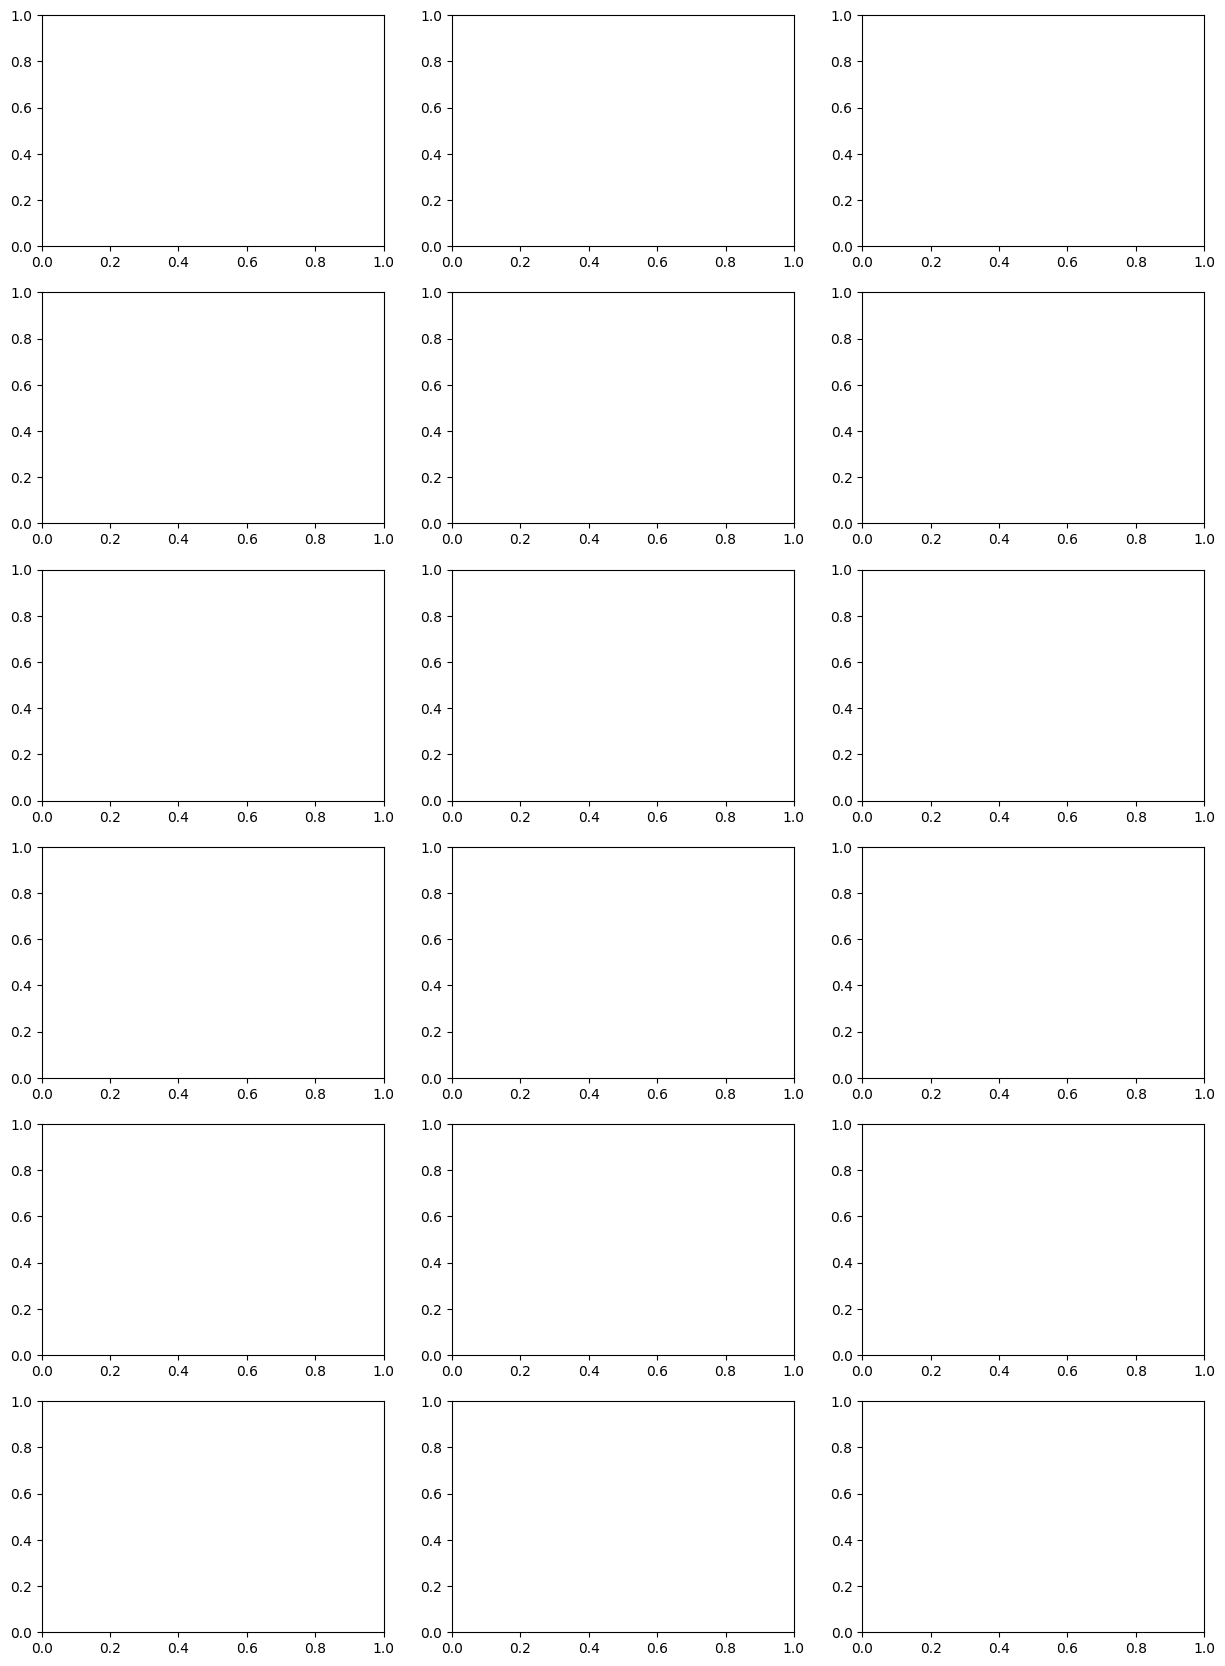

In [93]:
best_C = grid_result.best_params_.get('classifier__estimator__estimator__C', 1)
best_class_weight = grid_result.best_params_.get('classifier__estimator__estimator__class_weight', None)
best_loss = grid_result.best_params_.get('classifier__estimator__estimator__loss', "squared_hinge")

 
tfidf_vectorizer.fit(X_test_c)
feature_names = tfidf_vectorizer.get_feature_names_out()
 
viz_model = OneVsRestClassifier(CalibratedClassifierCV(
            LinearSVC(C = best_C, class_weight=best_class_weight, loss=best_loss, max_iter=3000), cv=3))

X_trans = tfidf_vectorizer.transform(X_test_c)
viz_model.fit(X_trans, y_test_merged_c)
 
# --- Step 4: Run it ---
print(" BLUE = Indicates YES | RED = Indicates NO")
plot_top_features(viz_model, feature_names, class_labels=list(y_test_merged_c.columns), top_n=7)
 

In [ ]:
y_test_pred = hermetic_model.predict(X_test_c)
 
y_test_labels = mlb.inverse_transform(y_test_merged.to_numpy())
y_pred_labels = mlb.inverse_transform(y_test_pred)
 
# 3. Create a DataFrame for Analysis
df_errors = pd.DataFrame({
    'Review': X_test_c.values,
    'True_Labels': y_test_labels,
    'Predicted_Labels': y_pred_labels
})
 
target_category = "Seafood restaurant" 
 
missed_reviews = df_errors[df_errors.apply(is_false_negative, axis=1)]
 
print(f"--- Examples of Missed '{target_category}' Reviews ---")

for i, row in missed_reviews.head(5).iterrows():
    print(f"\nExample {i+1}:")
    print(f"TRUE: {row['True_Labels']}")
    print(f"PRED: {row['Predicted_Labels']}")
    print(f"TEXT: {row['Review'][:700]}...") 
    print("-" * 50)
 